# Level 2 Task 4 - Restaurant Chains

## Objective
Identify restaurant chains present in the dataset and 
analyze their ratings and popularity across outlets.

Step 1 → Check which names appear more than once

Step 2 → Keep only restaurants that appear more than once. These are the chains

Step 3 → How many outlets does each chain have?

Step 4 → What is the average rating of each chain?

Step 5 → Which chain has the most votes?

Step 6 → Bar chart of top chains by outlet count and rating

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_excel('Restaurant Analysis.xlsx')
df.columns = df.columns.str.replace('ï»¿', '')

In [2]:
print(df['Restaurant Name'].value_counts().head(10))

Restaurant Name
Cafe Coffee Day     83
Domino's Pizza      79
Subway              63
Green Chick Chop    51
McDonald's          48
Keventers           34
Pizza Hut           30
Giani               29
Baskin Robbins      28
Barbeque Nation     26
Name: count, dtype: int64


#### Observation

The top 10 most repeated restaurant names are all chains 
with multiple outlets. Cafe Coffee Day is the largest chain 
with 83 outlets followed by Domino's Pizza with 79 outlets 
and Subway with 63 outlets.

### Identifying Chains and Non-Chains

Before filtering chains, we first verify how many restaurants 
appear only once (non-chains) and how many appear more than 
once (chains) in the dataset.

In [6]:
outlet_counts = df['Restaurant Name'].value_counts()

# Restaurants appearing only once
non_chains = outlet_counts[outlet_counts == 1]

# Restaurants appearing more than once
chains = outlet_counts[outlet_counts > 1]

print("Total unique restaurant names:", len(outlet_counts))
print("Non-chains (appear only once):", len(non_chains))
print("Chains (appear more than once):", len(chains))

Total unique restaurant names: 7446
Non-chains (appear only once): 6712
Chains (appear more than once): 734


#### Observation

Out of 7,446 unique restaurant names, 6,712 are non-chains 
appearing only once in the dataset. Only 734 restaurants 
are chains with more than one outlet. This means most 
restaurants in the dataset are unique individual restaurants 
and not part of a chain.

### Filtering Restaurant Chains

A restaurant is considered a chain if it has more than 
one outlet in the dataset. We filter out all restaurants 
that appear only once.

In [3]:
# Count outlets per restaurant
outlet_counts = df['Restaurant Name'].value_counts()

# Keep only restaurants with more than 1 outlet
chains = outlet_counts[outlet_counts > 1]

print("Total chains found:", len(chains))
print("\nTop 10 chains:")
print(chains.head(10))

Total chains found: 734

Top 10 chains:
Restaurant Name
Cafe Coffee Day     83
Domino's Pizza      79
Subway              63
Green Chick Chop    51
McDonald's          48
Keventers           34
Pizza Hut           30
Giani               29
Baskin Robbins      28
Barbeque Nation     26
Name: count, dtype: int64


#### Observation

There are 734 restaurant chains in the dataset. 
Cafe Coffee Day is the largest chain with 83 outlets 
followed by Domino's Pizza with 79 outlets and Subway 
with 63 outlets. All top 10 chains are well known 
brands which are commonly found across multiple cities.

### Analyzing Chain Ratings and Popularity

We calculate the average rating and average votes 
for each chain to compare their performance.

In [14]:
# Filter only chain restaurants from main dataframe
chain_df = df[df['Restaurant Name'].isin(chains.index)]

# Calculate average rating and votes per chain
chain_analysis = chain_df.groupby('Restaurant Name').agg(
    outlets=('Restaurant Name', 'count'), #number of outlets
    avg_rating=('Aggregate rating', 'mean'), #average rating
    avg_votes=('Votes', 'mean') #average vote
)

# Sort by number of outlets
chain_analysis = chain_analysis.sort_values('outlets', ascending=False)
print(chain_analysis.head(10))

                  outlets  avg_rating    avg_votes
Restaurant Name                                   
Cafe Coffee Day        83    2.419277    29.253012
Domino's Pizza         79    2.740506    84.088608
Subway                 63    2.907937    97.206349
Green Chick Chop       51    2.672549    18.901961
McDonald's             48    3.339583   110.229167
Keventers              34    2.870588    37.147059
Pizza Hut              30    3.320000   165.366667
Giani                  29    2.689655    29.448276
Baskin Robbins         28    1.860714    15.285714
Barbeque Nation        26    4.353846  1082.384615


#### Observation

Cafe Coffee Day has the most outlets with 83 but has an 
average rating of 2.42. Barbeque Nation has only 26 outlets 
but the highest rating of 4.35 and highest average votes of 
1,082. Despite Cafe Coffee Day having more outlets and 
likely more customer visits, Barbeque Nation has significantly 
higher votes. This suggests that customers of premium dining 
experiences are more likely to leave ratings online compared 
to customers of budget friendly chains.

### Visualizing Chain Analysis

We create two charts to compare chains by number of 
outlets and by average rating.

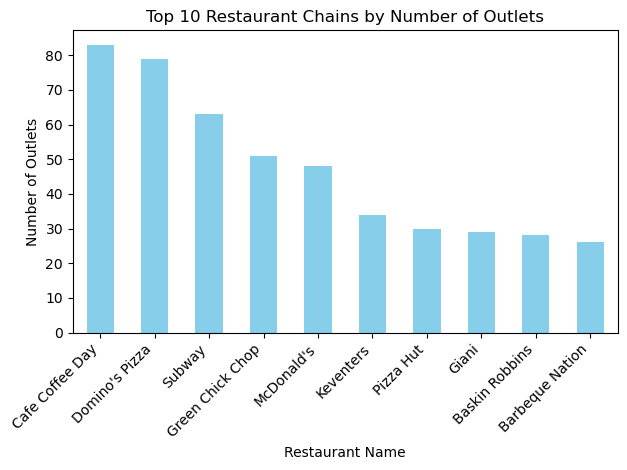

In [15]:
top10 = chain_analysis.head(10)

top10['outlets'].plot(kind='bar', color='skyblue')
plt.title('Top 10 Restaurant Chains by Number of Outlets')
plt.xlabel('Restaurant Name')
plt.ylabel('Number of Outlets')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [16]:
# Check outlet count for top rated chains
top10_rated = chain_analysis.sort_values('avg_rating', ascending=False).head(10)
print(top10_rated[['outlets', 'avg_rating']])

                           outlets  avg_rating
Restaurant Name                               
Talaga Sampireun                 3       4.900
Silantro Fil-Mex                 2       4.850
AB's Absolute Barbecues          2       4.850
AB's - Absolute Barbecues        4       4.825
Naturals Ice Cream               2       4.800
Gymkhana                         2       4.700
The Cheesecake Factory           2       4.650
Dishoom                          2       4.600
Garota de Ipanema                2       4.600
Chili's                          5       4.580


#### Note

The top rated chains all have only 2 to 5 outlets. 
A small number of outlets means the average rating is 
based on very few data points and is not reliable. 
We filter chains with atleast 10 outlets for a fair comparison.

In [17]:
# Filter chains with atleast 10 outlets
reliable_chains = chain_analysis[chain_analysis['outlets'] >= 10]

# Sort by average rating
reliable_chains = reliable_chains.sort_values('avg_rating', ascending=False)

# Show top 10
print(reliable_chains.head(10))

                 outlets  avg_rating    avg_votes
Restaurant Name                                  
Barbeque Nation       26    4.353846  1082.384615
Starbucks             18    3.805556   396.611111
Haldiram's            16    3.625000   282.812500
Chaayos               18    3.538889   137.388889
Burger King           16    3.406250   288.562500
McDonald's            48    3.339583   110.229167
Pizza Hut             30    3.320000   165.366667
Gopala                10    3.290000    26.400000
Bikanervala           14    3.192857   212.857143
Behrouz Biryani       13    3.184615    39.153846


#### Observation

After filtering chains with atleast 10 outlets, the results 
are more reliable. Barbeque Nation still leads with the 
highest rating of 4.35 and highest votes of 1,082 confirming 
our earlier finding. The difference now is that all chains 
in this list have enough outlets to make the average rating 
meaningful and trustworthy.

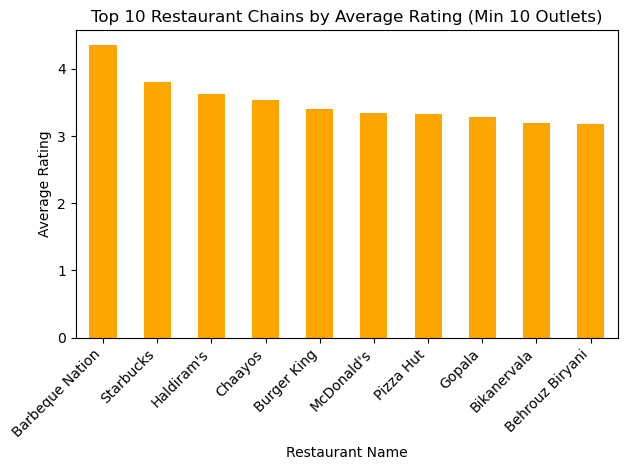

In [18]:
reliable_chains.head(10)['avg_rating'].plot(kind='bar', color='orange')
plt.title('Top 10 Restaurant Chains by Average Rating (Min 10 Outlets)')
plt.xlabel('Restaurant Name')
plt.ylabel('Average Rating')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#### Observation

The bar chart clearly shows Barbeque Nation as the highest 
rated chain with 4.35, significantly ahead of Starbucks at 
3.81. The remaining 8 chains have ratings between 3.1 and 
3.6 which are relatively close to each other. This chart 
only includes chains with atleast 10 outlets to ensure 
the ratings are based on enough data to be reliable.